# KNN

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

![Iris Data](https://k3-production-bucket.s3.amazonaws.com/uploads/cD6ccKKMJJW8rENfe_51518iris%20img1.png)

![Dataset](https://codesignal-assets.s3.amazonaws.com/uploads/1698069484361/unit1_lesson_01.png)

In [ ]:
# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

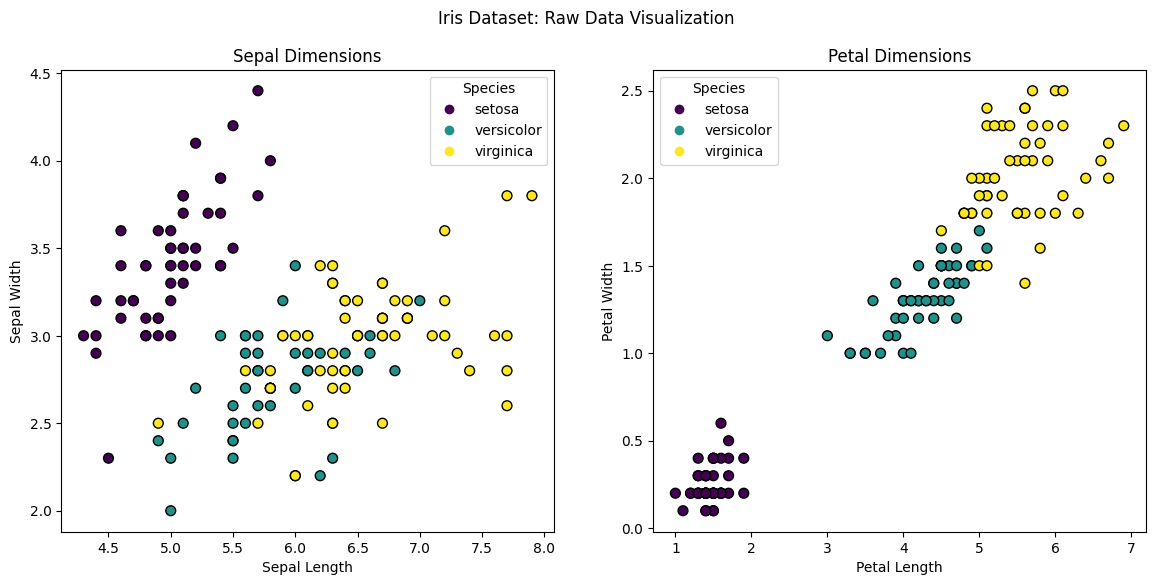

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Sepal Length vs Sepal Width
scatter1 = ax1.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=50)
ax1.set_xlabel('Sepal Length')
ax1.set_ylabel('Sepal Width')
ax1.set_title('Sepal Dimensions')
ax1.legend(handles=scatter1.legend_elements()[0], labels=list(target_names), title="Species")

# Plot 2: Petal Length vs Petal Width
scatter2 = ax2.scatter(X[:, 2], X[:, 3], c=y, cmap='viridis', edgecolor='k', s=50)
ax2.set_xlabel('Petal Length')
ax2.set_ylabel('Petal Width')
ax2.set_title('Petal Dimensions')
ax2.legend(handles=scatter2.legend_elements()[0], labels=list(target_names), title="Species")

plt.suptitle("Iris Dataset: Raw Data Visualization")
plt.show()


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# KNN classifier
knn = KNeighborsClassifier(n_neighbors=3)

# Train
knn.fit(X_train, y_train)


KNeighborsClassifier(n_neighbors=3)

In [ ]:
# Predict
y_pred = knn.predict(X_test)

# accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=iris.target_names))

# predict a random new flower: [Sepal Len, Sepal Wid, Petal Len, Petal Wid]
new_flower = [[5.1, 3.5, 1.4, 0.2]]
prediction = knn.predict(new_flower)
print(f"New flower prediction: {iris.target_names[prediction][0]}")

Model Accuracy: 100.00%

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

New flower prediction: setosa


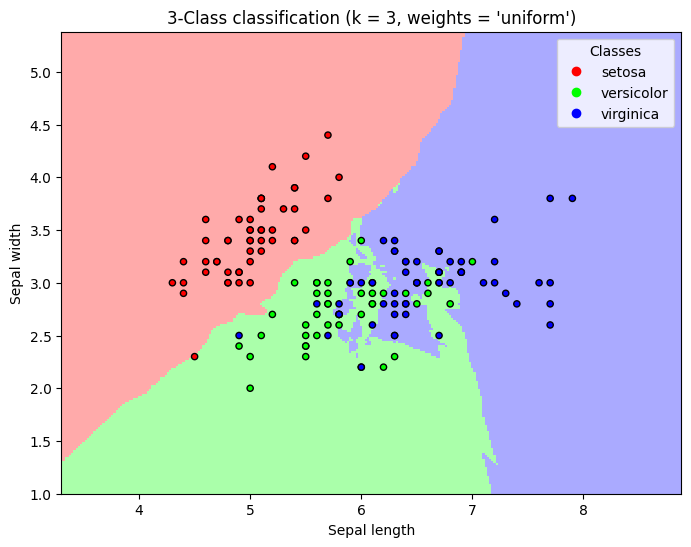

In [ ]:
# Take only the first two features for plotting purposes
X_vis = iris.data[:, :2]
y_vis = iris.target

# Create a new KNN instance for the plot
clf = KNeighborsClassifier(n_neighbors=5)
clf.fit(X_vis, y_vis)

# Create color maps for the plot
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

# Calculate min, max and limits for the plot background
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict class for every point in the mesh (background color)
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plotting
plt.figure(figsize=(8, 6))
plt.pcolormesh(xx, yy, Z, cmap=cmap_light, shading='auto')

# Plot also the training points
scatter = plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, cmap=cmap_bold, edgecolor='k', s=20)

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title("3-Class classification (k = 3, weights = 'uniform')")
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')

# Add a legend manually
handles, _ = scatter.legend_elements()
plt.legend(handles, iris.target_names, title="Classes")

plt.show()